In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch

In [18]:
ALL_Data =  pd.read_csv("All_features.csv",index_col="Date",parse_dates=["Date"]).dropna()
df = ALL_Data["HDFCBANK"].to_frame()
df

,HDFCBANK
Date,
2015-01-05,500.999146
2015-01-06,483.090759
2015-01-07,482.703583
2015-01-08,485.898041
2015-01-09,479.121918
...,...
2025-12-22,1233.199951
2025-12-23,1225.000000
2025-12-24,1226.300049


In [52]:
# Step 2: Clean data
# df.columns = ['Close']  # Rename column to 'Close'
df = df[df['HDFCBANK'] > 0]  # Keep only positive prices

print("Cleaned data shape:", df.shape)
print(df.head())

Cleaned data shape: (2342, 3)
              HDFCBANK  simple_return  log_return
Date                                             
2015-01-05  500.999146            NaN         NaN
2015-01-06  483.090759      -0.035745   -0.036400
2015-01-07  482.703583      -0.000801   -0.000802
2015-01-08  485.898041       0.006618    0.006596
2015-01-09  479.121918      -0.013946   -0.014044


In [54]:
# Step 3: Calculate returns (use your existing log_return)
returns = df['log_return'].dropna()

print("Returns shape:", returns.shape)
print("Returns summary:")
print(returns.describe())
print("\nFirst 5 returns:", returns.head().values)

Returns shape: (2341,)
Returns summary:
count    2341.000000
mean        0.000389
std         0.022461
min        -0.327499
25%        -0.009772
50%         0.000693
75%         0.010756
max         0.177985
Name: log_return, dtype: float64

First 5 returns: [-0.03639985 -0.00080178  0.00659604 -0.01404372  0.01911122]


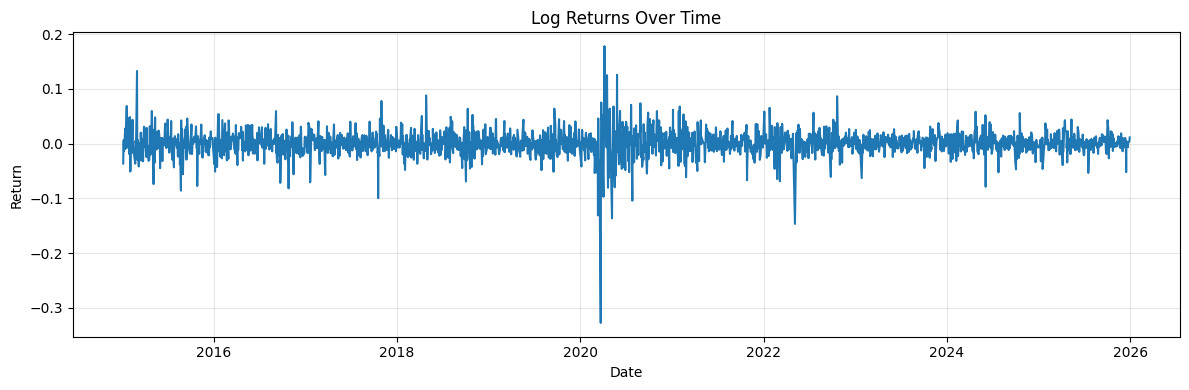

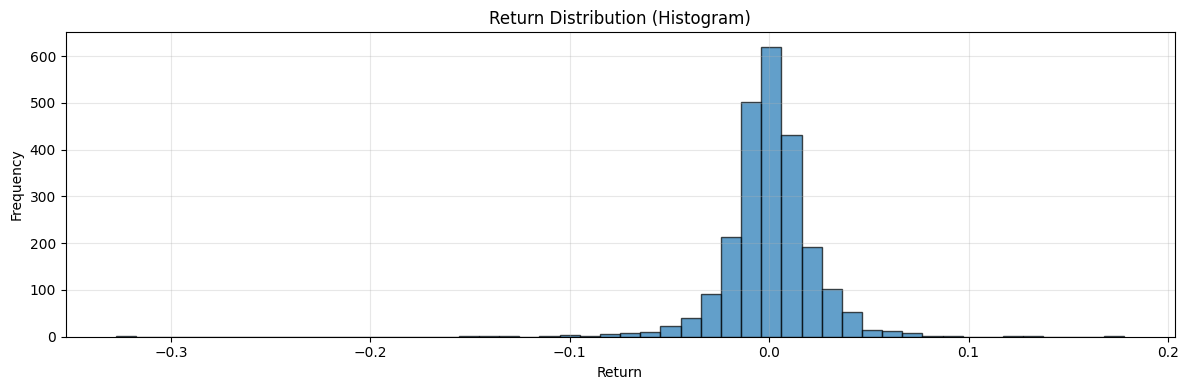

In [56]:
# Step 4: EDA
import matplotlib.pyplot as plt

# Plot 1: Returns over time
plt.figure(figsize=(12, 4))
plt.plot(returns.index, returns.values)
plt.title('Log Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Return')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Return histogram
plt.figure(figsize=(12, 4))
plt.hist(returns, bins=50, edgecolor='black', alpha=0.7)
plt.title('Return Distribution (Histogram)')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(returns)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -10.488216318497702
p-value: 1.1652969410808626e-18
Critical Values:
   1%: -3.433173007001078
   5%: -2.8627871467151595
   10%: -2.56743391172832


In [60]:
# Step 6: Mean model (optional)
mean_return = returns.mean()
df["demeaned_return"] = df["log_return"] - mean_return

print("Mean return:", mean_return)
print(df[["log_return", "demeaned_return"]].head())

Mean return: 0.00038918808365536795
            log_return  demeaned_return
Date                                   
2015-01-05         NaN              NaN
2015-01-06   -0.036400        -0.036789
2015-01-07   -0.000802        -0.001191
2015-01-08    0.006596         0.006207
2015-01-09   -0.014044        -0.014433


In [62]:
# Step 7: Choose lambda
lam = 0.94

print("Chosen lambda:", lam)

Chosen lambda: 0.94


In [64]:
# Step 8: Compute EWMA volatility
lam = 0.94

r = df["demeaned_return"].dropna()

ewma_var = np.zeros(len(r))
ewma_var[0] = r.iloc[:30].var()   # initial variance from first 30 returns

for t in range(1, len(r)):
    ewma_var[t] = lam * ewma_var[t-1] + (1 - lam) * r.iloc[t-1]**2

ewma_vol = np.sqrt(ewma_var)

df_ewma = df.loc[r.index].copy()
df_ewma["ewma_var"] = ewma_var
df_ewma["ewma_vol"] = ewma_vol

print(df_ewma[["demeaned_return", "ewma_var", "ewma_vol"]].head())

            demeaned_return  ewma_var  ewma_vol
Date                                           
2015-01-06        -0.036789  0.000784  0.028009
2015-01-07        -0.001191  0.000819  0.028611
2015-01-08         0.006207  0.000770  0.027741
2015-01-09        -0.014433  0.000726  0.026939
2015-01-13         0.018722  0.000695  0.026357


In [66]:
# Step 9: Rolling forecasts
df_ewma["forecast_var"] = df_ewma["ewma_var"].shift(1)
df_ewma["forecast_vol"] = np.sqrt(df_ewma["forecast_var"])

print(df_ewma[["ewma_var", "forecast_var", "forecast_vol"]].head())

            ewma_var  forecast_var  forecast_vol
Date                                            
2015-01-06  0.000784           NaN           NaN
2015-01-07  0.000819      0.000784      0.028009
2015-01-08  0.000770      0.000819      0.028611
2015-01-09  0.000726      0.000770      0.027741
2015-01-13  0.000695      0.000726      0.026939


In [68]:
# Step 10: Compare with realized volatility
df_ewma["realized_var"] = df_ewma["demeaned_return"]**2
df_ewma["realized_vol"] = np.sqrt(df_ewma["realized_var"])

print(df_ewma[["forecast_var", "realized_var", "forecast_vol", "realized_vol"]].head())

            forecast_var  realized_var  forecast_vol  realized_vol
Date                                                              
2015-01-06           NaN      0.001353           NaN      0.036789
2015-01-07      0.000784      0.000001      0.028009      0.001191
2015-01-08      0.000819      0.000039      0.028611      0.006207
2015-01-09      0.000770      0.000208      0.027741      0.014433
2015-01-13      0.000726      0.000351      0.026939      0.018722


In [70]:
# Step 11: RMSE
eval_df = df_ewma.dropna(subset=["forecast_var", "realized_var"]).copy()

rmse = np.sqrt(np.mean((eval_df["forecast_var"] - eval_df["realized_var"])**2))
print("RMSE:", rmse)

RMSE: 0.002583012503160654


In [72]:
# Step 12: MAE
mae = np.mean(np.abs(eval_df["forecast_var"] - eval_df["realized_var"]))
print("MAE:", mae)

MAE: 0.000590857535928515


In [74]:
# Step 13: MSE
mse = np.mean((eval_df["forecast_var"] - eval_df["realized_var"])**2)
print("MSE:", mse)

MSE: 6.67195359148427e-06


In [76]:
# Step 14: QLIKE
eps = 1e-12
fv = np.maximum(eval_df["forecast_var"].values, eps)
rv = np.maximum(eval_df["realized_var"].values, eps)

qlike = np.mean(np.log(fv) + rv / fv)
print("QLIKE:", qlike)

QLIKE: -6.7956974403401


In [78]:
# Step 15: VaR
from scipy.stats import norm

alpha = 0.05
z = norm.ppf(alpha)

df_ewma["VaR_95"] = z * df_ewma["forecast_vol"]

print(df_ewma[["forecast_vol", "VaR_95"]].head())

            forecast_vol    VaR_95
Date                              
2015-01-06           NaN       NaN
2015-01-07      0.028009 -0.046070
2015-01-08      0.028611 -0.047062
2015-01-09      0.027741 -0.045631
2015-01-13      0.026939 -0.044311


In [80]:
# Step 16: Expected Shortfall
from scipy.stats import norm

alpha = 0.05
z = norm.ppf(alpha)
pdf_z = norm.pdf(z)

df_ewma["ES_95"] = -df_ewma["forecast_vol"] * (pdf_z / alpha)

print(df_ewma[["forecast_vol", "VaR_95", "ES_95"]].head())

            forecast_vol    VaR_95     ES_95
Date                                        
2015-01-06           NaN       NaN       NaN
2015-01-07      0.028009 -0.046070 -0.057774
2015-01-08      0.028611 -0.047062 -0.059017
2015-01-09      0.027741 -0.045631 -0.057223
2015-01-13      0.026939 -0.044311 -0.055568


In [82]:
# Step 17: Backtesting
df_ewma["VaR_breach"] = (df_ewma["demeaned_return"] < df_ewma["VaR_95"]).astype(int)

breaches = df_ewma["VaR_breach"].sum()
total = df_ewma["VaR_breach"].count()

print("Total observations:", total)
print("VaR breaches:", breaches)
print("Breach rate:", breaches / total)

Total observations: 2341
VaR breaches: 112
Breach rate: 0.04784280222127296


In [84]:
# Step 18: Kupiec test
from scipy.stats import chi2
import numpy as np

alpha = 0.05
x = breaches
n = total
p_hat = x / n

LR_uc = -2 * (
    (n - x) * np.log((1 - alpha) / (1 - p_hat)) +
    x * np.log(alpha / p_hat)
)

p_value = 1 - chi2.cdf(LR_uc, df=1)

print("Kupiec LR statistic:", LR_uc)
print("Kupiec p-value:", p_value)

Kupiec LR statistic: 0.23253826765508379
Kupiec p-value: 0.6296480951140405


In [86]:
# Step 19: Christoffersen test
breach = df_ewma["VaR_breach"].dropna().values

n00 = n01 = n10 = n11 = 0

for i in range(1, len(breach)):
    prev_b = breach[i-1]
    curr_b = breach[i]
    if prev_b == 0 and curr_b == 0:
        n00 += 1
    elif prev_b == 0 and curr_b == 1:
        n01 += 1
    elif prev_b == 1 and curr_b == 0:
        n10 += 1
    elif prev_b == 1 and curr_b == 1:
        n11 += 1

pi0 = n01 / (n00 + n01)
pi1 = n11 / (n10 + n11)
pi = (n01 + n11) / (n00 + n01 + n10 + n11)

LR_ind = -2 * (
    (n00 + n01) * np.log(1 - pi) + (n10 + n11) * np.log(pi)
    - (n00 * np.log(1 - pi0) + n01 * np.log(pi0) +
       n10 * np.log(1 - pi1) + n11 * np.log(pi1))
)

p_value_ind = 1 - chi2.cdf(LR_ind, df=1)

print("n00, n01, n10, n11:", n00, n01, n10, n11)
print("Christoffersen LR statistic:", LR_ind)
print("Christoffersen p-value:", p_value_ind)

n00, n01, n10, n11: 2124 104 104 8
Christoffersen LR statistic: 1.2619871962936031
Christoffersen p-value: 0.26127527638225934


In [88]:
# Step 20: Stress testing
stress_shocks = [-0.02, -0.05, -0.10]

latest_vol = df_ewma["forecast_vol"].dropna().iloc[-1]
latest_var = df_ewma["VaR_95"].dropna().iloc[-1]
latest_es = df_ewma["ES_95"].dropna().iloc[-1]

print("Latest forecast vol:", latest_vol)
print("Latest VaR 95%:", latest_var)
print("Latest ES 95%:", latest_es)

for shock in stress_shocks:
    breach_var = shock < latest_var
    breach_es = shock < latest_es
    print(f"Shock {shock:.0%} | Breaches VaR? {breach_var} | Breaches ES? {breach_es}")

Latest forecast vol: 0.013171501971167936
Latest VaR 95%: -0.021665192789674055
Latest ES 95%: -0.0271690258100374
Shock -2% | Breaches VaR? False | Breaches ES? False
Shock -5% | Breaches VaR? True | Breaches ES? True
Shock -10% | Breaches VaR? True | Breaches ES? True
